In [1]:
import pandas as pd
import numpy as np
from tqdm import tqdm

# **Pretrained Models for seniment classification**

In [4]:
reviews = pd.read_csv("cleaned_comments.csv")

print(len(reviews))
reviews.head(5)

41586


,author,updated_at,like_count,text,video_id,public,language,translated_text,is_relevant,char_count,word_count,sentence_count
0,@kingsman1713,2020-03-30T00:09:44Z,41736,The guy who stay in the ship for 20 years. He'...,j3DuONZb3Ik,True,en,The guy who stay in the ship for 20 years. he ...,True,72,16,2
1,@IkanGelamaKuning,2021-08-18T15:33:15Z,37032,A husband waiting for his wife shopping feels ...,JqKa6qyVYgg,True,en,A husband waiting for his wife shopping feels ...,True,118,22,2
2,@stevedevries2891,2021-01-05T01:33:47Z,17975,My wife keeps asking me to dust my office. I'm...,j3DuONZb3Ik,True,en,My wife keeps asking me to dust my office. I a...,True,90,22,2
3,@joshfromdundermifflin8973,2020-03-05T18:54:19Z,15427,The scene where cooper comes back to the ship ...,j3DuONZb3Ik,True,en,The scene where cooper comes back to the ship ...,True,154,28,1
4,@Dcook85,2014-11-24T01:48:48Z,15359,I was disappointed to see that Christopher Nol...,R1cexcjdyIE,True,en,I was disappointed to see that Christopher Nol...,True,167,32,2


## **TweetNLP**

In [5]:
!pip install tweetnlp

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.4/109.4 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.8/40.8 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.8/73.8 MB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 472.3/472.3 kB 38.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 80.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.5/87.5 kB 9.0 MB/s eta 0:00:00
  Attempting uninstall: pydantic-core
    Found existing installation: pydantic_core 2.33.2
    Uninstalling pydantic_core-2.33.2:
      Successfully uninstalled pydantic_core-2.33.2
  Attempting uninstall: pydantic
    Found existing installation: pydantic 2.11.10
    Uninstalling pydantic-2.11.10:
      Successfully uninstalled pydantic-2.11.10
ERROR: pip's dependency resolver does not currently take into account all the packages that are ins

In [6]:
import tweetnlp

In [7]:
# Loading TweetNLP and initialize the sentiment model
model = tweetnlp.load_model('sentiment')

/usr/local/lib/python3.12/dist-packages/transformers/models/auto/configuration_auto.py:1318: FutureWarning: The `use_auth_token` argument is deprecated and will be removed in v5 of Transformers. Please use `token` instead.
  warnings.warn(


config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/models/auto/tokenization_auto.py:1025: FutureWarning: The `use_auth_token` argument is deprecated and will be removed in v5 of Transformers. Please use `token` instead.
  warnings.warn(


vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/models/auto/auto_factory.py:492: FutureWarning: The `use_auth_token` argument is deprecated and will be removed in v5 of Transformers. Please use `token` instead.
  warnings.warn(


pytorch_model.bin:   0%|          | 0.00/501M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/501M [00:00<?, ?B/s]

Some weights of the model checkpoint at cardiffnlp/twitter-roberta-base-sentiment-latest were not used when initializing RobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


In [8]:
#emotion model
emotion_model = tweetnlp.load_model('emotion')

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/409 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

In [9]:
#Function to predict the sentiment of a given review, 1 and 0 for positive and negative respectively
def getTweetNLPSentiment(text):
    result = model.sentiment(text)
    label = result['label']
    return 1 if label == 'positive' else 0

In [10]:
tqdm.pandas()

In [12]:
# Using full dataset for lightweight models, sampled for heavier neural models
# 1000 representative comments sampled for TweetNLP due to computational constraints
reviews_sample = reviews.sample(1000, random_state=42).copy()
reviews_sample["TweetNLP"] = reviews_sample["translated_text"].progress_apply(getTweetNLPSentiment)

100%|██████████| 1000/1000 [03:54<00:00,  4.27it/s]


##Vader

In [13]:
!pip install vaderSentiment

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 3.9 MB/s eta 0:00:00


In [14]:
#import
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

In [15]:
# Initialize VADER analyzer
analyzer = SentimentIntensityAnalyzer()

In [16]:
# VADER returns a compound score between -1 and 1
# >= 0.05 is positive, <= -0.05 is negative, in between is neutral
def getVaderSentiment(text):
    scores = analyzer.polarity_scores(text)
    compound = scores['compound']
    if compound >= 0.05:
        return 1
    elif compound <= -0.05:
        return -1
    else:
        return 0

In [17]:
# Apply VADER to full dataset
reviews["Vader"] = reviews["translated_text"].progress_apply(getVaderSentiment)

100%|██████████| 41586/41586 [00:21<00:00, 1965.98it/s]


## **Other Tools**

Compare Vader with Tweetnlp in term of similarity with provided sentiment and in term of time

In [18]:
!pip install transformers torch

In [19]:
from transformers import pipeline
import time

# RoBERTa fine-tuned on Twitter/social media data, well suited for YouTube comments
roberta_model = pipeline(
    "sentiment-analysis",
    model="cardiffnlp/twitter-roberta-base-sentiment",
    truncation=True,
    max_length=512
)

# LABEL_0 = negative, LABEL_1 = neutral, LABEL_2 = positive
def getRobertaSentiment(text):
    result = roberta_model(text)[0]
    if result['label'] == 'LABEL_2':
        return 1
    elif result['label'] == 'LABEL_0':
        return -1
    else:
        return 0

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/747 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

Device set to use cpu


In [20]:
# Multilingual BERT fine-tuned on star reviews
# Returns 1-5 stars, 4+ is positive, 3 is neutral, below 3 is negative
bert_model = pipeline(
    "sentiment-analysis",
    model="nlptown/bert-base-multilingual-uncased-sentiment",
    truncation=True,
    max_length=512
)

def getBertSentiment(text):
    result = bert_model(text)[0]
    stars = int(result['label'][0])
    if stars >= 4:
        return 1
    elif stars == 3:
        return 0
    else:
        return -1

config.json:   0%|          | 0.00/953 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/669M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/39.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Device set to use cpu


In [21]:
# Apply both transformer models to the 1000 sample
# Heavy models so sampling is necessary due to computational constraints
tqdm.pandas()

start = time.time()
reviews_sample["RoBERTa"] = reviews_sample["translated_text"].progress_apply(getRobertaSentiment)
roberta_time = time.time() - start

100%|██████████| 1000/1000 [05:25<00:00,  3.07it/s]


In [22]:
start = time.time()
reviews_sample["BERT_NLP"] = reviews_sample["translated_text"].progress_apply(getBertSentiment)
bert_time = time.time() - start

100%|██████████| 1000/1000 [03:42<00:00,  4.50it/s]


In [23]:
import time

# Agreement between models shows consistency across different approaches
# Since no ground truth exists, inter-model agreement is used as a proxy for reliability
agreement = (reviews_sample["TweetNLP"] == reviews_sample["RoBERTa"]).mean()
print(f"TweetNLP vs RoBERTa agreement: {agreement:.3f}")

agreement2 = (reviews_sample["TweetNLP"] == reviews_sample["BERT_NLP"]).mean()
print(f"TweetNLP vs BERT agreement: {agreement2:.3f}")

agreement3 = (reviews_sample["RoBERTa"] == reviews_sample["BERT_NLP"]).mean()
print(f"RoBERTa vs BERT agreement: {agreement3:.3f}")

print("\n=== Time taken (seconds) ===")
print(f"RoBERTa  : {roberta_time:.2f}s")
print(f"BERT_NLP : {bert_time:.2f}s")

TweetNLP vs RoBERTa agreement: 0.662
TweetNLP vs BERT agreement: 0.463
RoBERTa vs BERT agreement: 0.640

=== Time taken (seconds) ===
RoBERTa  : 325.73s
BERT_NLP : 222.11s


In [24]:
# Compare inference speed between rule-based (VADER) and neural (TweetNLP) models
# Compare inference speed on same sample for fair comparison
print("=== Time Comparison ===")

start = time.time()
reviews_sample["translated_text"].apply(getVaderSentiment)
print(f"VADER    : {time.time() - start:.2f}s")

start = time.time()
reviews_sample["translated_text"].apply(getTweetNLPSentiment)
print(f"TweetNLP : {time.time() - start:.2f}s")

=== Time Comparison ===
VADER    : 0.48s
TweetNLP : 193.65s


# **Sentiment Analysis**

so now that we have sentiments, we can analyse the reviews and make some observation and extract insights

### **Word Cloud**

In [25]:
#install and import worldcloud and matplotlib
!pip install wordcloud

In [26]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

In [27]:
# Combine all positive and negative comments into single strings
# Using RoBERTa as the sentiment source since it performed best for social media text
positive_text = " ".join(reviews_sample[reviews_sample["RoBERTa"] == 1]["translated_text"])
negative_text = " ".join(reviews_sample[reviews_sample["RoBERTa"] == -1]["translated_text"])

In [28]:
# Function to generate word cloud from a string of text
def getWordCloud(text):
    wc = WordCloud(
        width=800,
        height=400,
        background_color="white",
        max_words=100,
        collocations=False
    ).generate(text)
    return wc

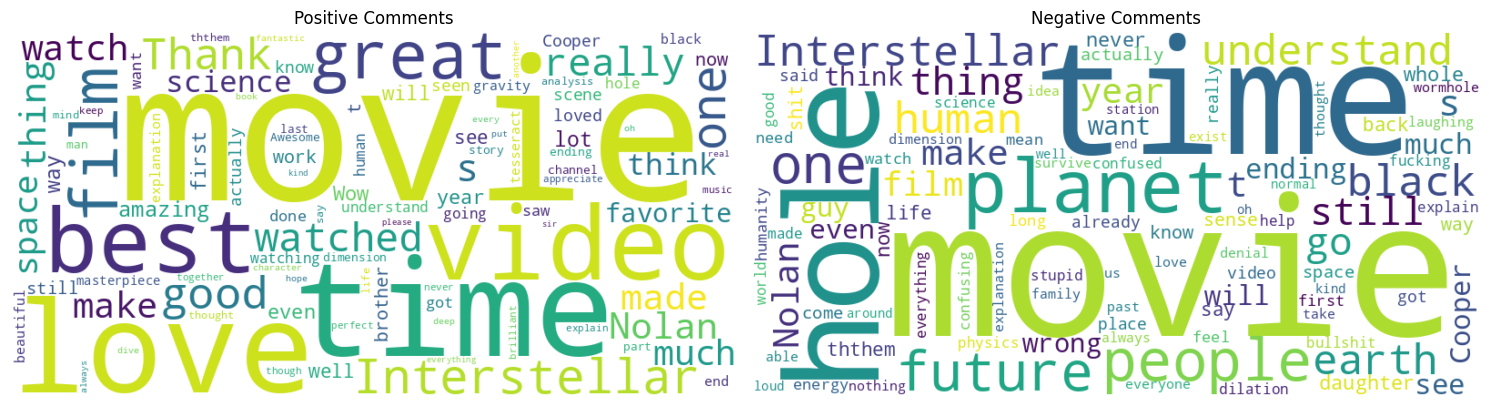

In [29]:
# Visualize most frequent words in positive vs negative Interstellar comments
plt.figure(figsize=(15, 8))

plt.subplot(1, 2, 1)
plt.imshow(getWordCloud(positive_text), interpolation="bilinear")
plt.axis("off")
plt.title("Positive Comments")

plt.subplot(1, 2, 2)
plt.imshow(getWordCloud(negative_text), interpolation="bilinear")
plt.axis("off")
plt.title("Negative Comments")

plt.tight_layout()
plt.show()

# Positive Comments:

Dominant words are love, best, great, movie, film -- viewers are expressing strong admiration for the film overall.
Words like masterpiece, amazing, favorite, science, space confirm appreciation for both the storytelling and scientific depth.

# Negative Comments:

confusing, understand, explain, wrong are dominant -- difficulty understanding the plot is the #1 complaint in negative comments.
ending, planet, future, earth appear prominently -- the ending and sci-fi concepts are the second biggest source of frustration.
stupid appearing confirms some viewers rejected the film's complexity entirely.

### **Using TFIDF/BOW**

In [30]:
from sklearn.feature_extraction.text import CountVectorizer

In [31]:
# CountVectorizer extracts top N most frequent words from a corpus
vectorizer = CountVectorizer(max_features=20, stop_words='english')

In [32]:
# Function to vectorize text and return word counts and feature names
def vecDetails(texts):
    X = vectorizer.fit_transform(texts)
    word_counts = X.toarray().sum(axis=0)
    feature_names = vectorizer.get_feature_names_out()
    return word_counts, feature_names

In [33]:
# Get top words for positive and negative comments using RoBERTa sentiment labels
wc_p, w_p = vecDetails(reviews_sample[reviews_sample["RoBERTa"] == 1]["translated_text"])
wc_n, w_n = vecDetails(reviews_sample[reviews_sample["RoBERTa"] == -1]["translated_text"])

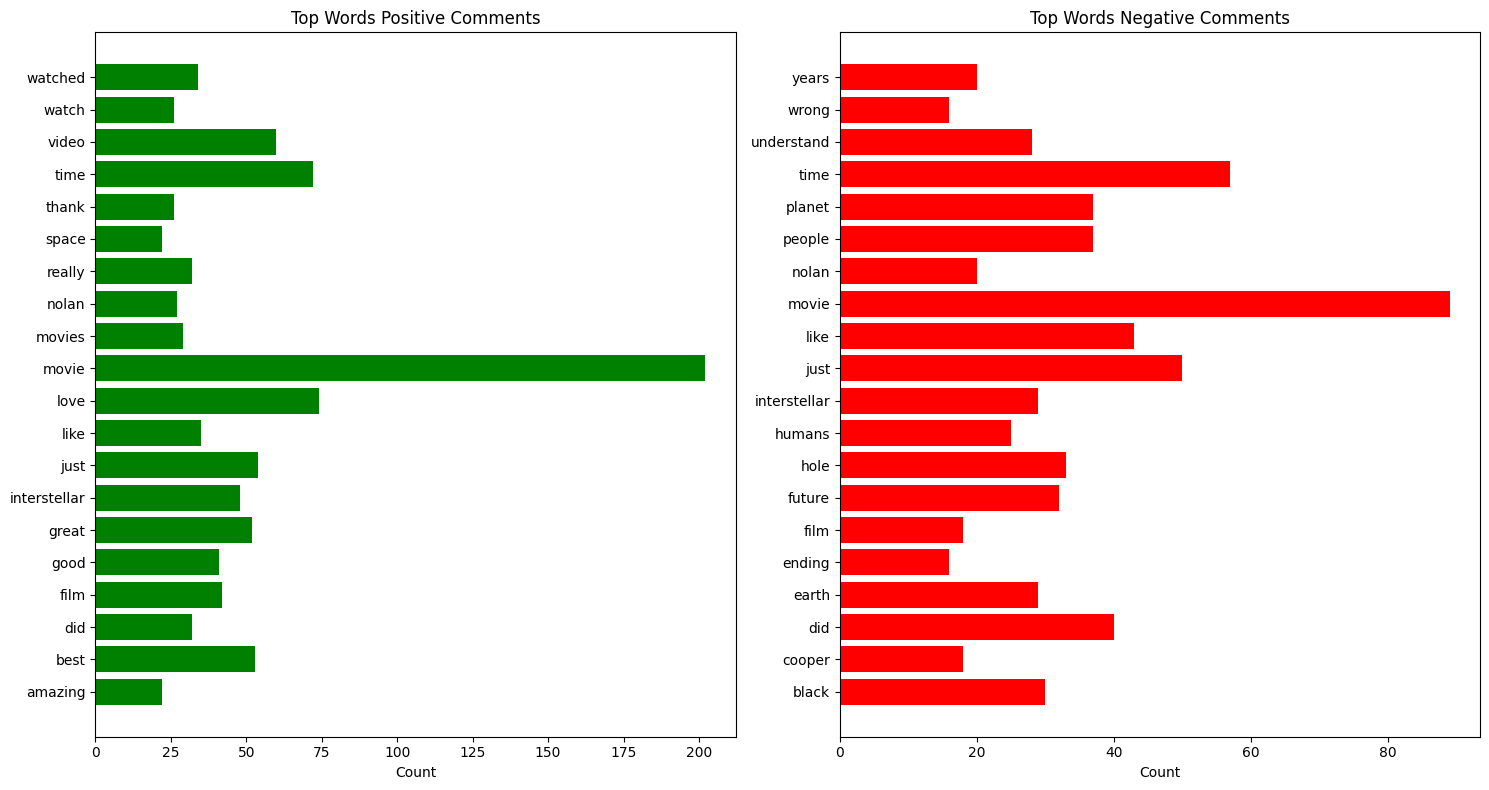

In [34]:
# Visualize top words in positive vs negative comments as horizontal bar charts
plt.figure(figsize=(15, 8))

plt.subplot(1, 2, 1)
plt.barh(w_p, wc_p, color='green')
plt.title("Top Words Positive Comments")
plt.xlabel("Count")

plt.subplot(1, 2, 2)
plt.barh(w_n, wc_n, color='red')
plt.title("Top Words Negative Comments")
plt.xlabel("Count")

plt.tight_layout()
plt.show()

#**Emotion model**

In [35]:
# Apply emotion model to the sample to extract fine-grained emotions from Interstellar comments
# Emotions like joy, surprise, fear are more meaningful for movie discussion than binary sentiment
def getEmotion(text):
    result = emotion_model.emotion(text)
    return result['label']

reviews_sample["Emotion"] = reviews_sample["translated_text"].progress_apply(getEmotion)

100%|██████████| 1000/1000 [03:30<00:00,  4.75it/s]


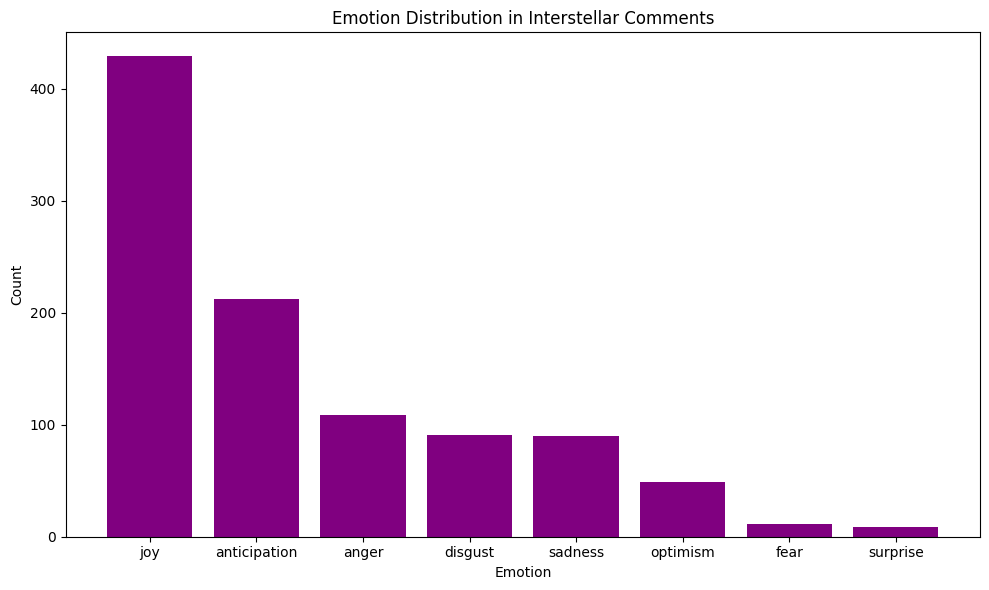

In [36]:
# Visualize emotion distribution across all sampled comments
emotion_counts = reviews_sample["Emotion"].value_counts()

plt.figure(figsize=(10, 6))
plt.bar(emotion_counts.index, emotion_counts.values, color='purple')
plt.title("Emotion Distribution in Interstellar Comments")
plt.xlabel("Emotion")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [38]:
# Add VADER results from full dataset to sample
reviews_sample["Vader"] = reviews["Vader"].loc[reviews_sample.index]
reviews_sample.to_csv("../data/sentiment_results.csv", index=False)